DT = 0.4 ns/sample
Range θ: [0.0, 70.0]° con step di scansione 0.1°
Osservabili nel χ²: ['Q_SUM', 'N_peaks_SUM', 'OT_SUM']
Funzioni caricate.
Cerco file .npz in: /Users/benussi/Testbeam2026_WC_single/data
Trovati 200 file totali.

Eventi totali (θ ≤ 70.0°): 197454
=== Calibrazione X ===
  log(Q_R/Q_L): slope = -0.0018915, intercept = -0.072, sigma_X = 293.1 mm
  Δt:           slope = +0.014354, intercept = +0.564, sigma_X = 92.5 mm

Eventi con X_rec valido: 196481/197454
sigma X combinata (training stesso): 266.8 mm
Eventi validi: 196481
  Training: 98240
  Test:     98241
Griglia θ: [ 0. 10. 20. 30. 40. 50. 60. 70.]
Griglia X: [-400. -200.    0.  200.  400.]

Numero medio di eventi per cella (θ, X) di training: 2456
Min: 2278, Max: 2584
=== Matrice di covarianza globale C (sui residui) ===
                        Q_SUM    N_peaks_SUM         OT_SUM
Q_SUM             +160706.660        +56.287       +710.680
N_peaks_SUM           +56.287         +0.694         +0.271
OT_SUM            

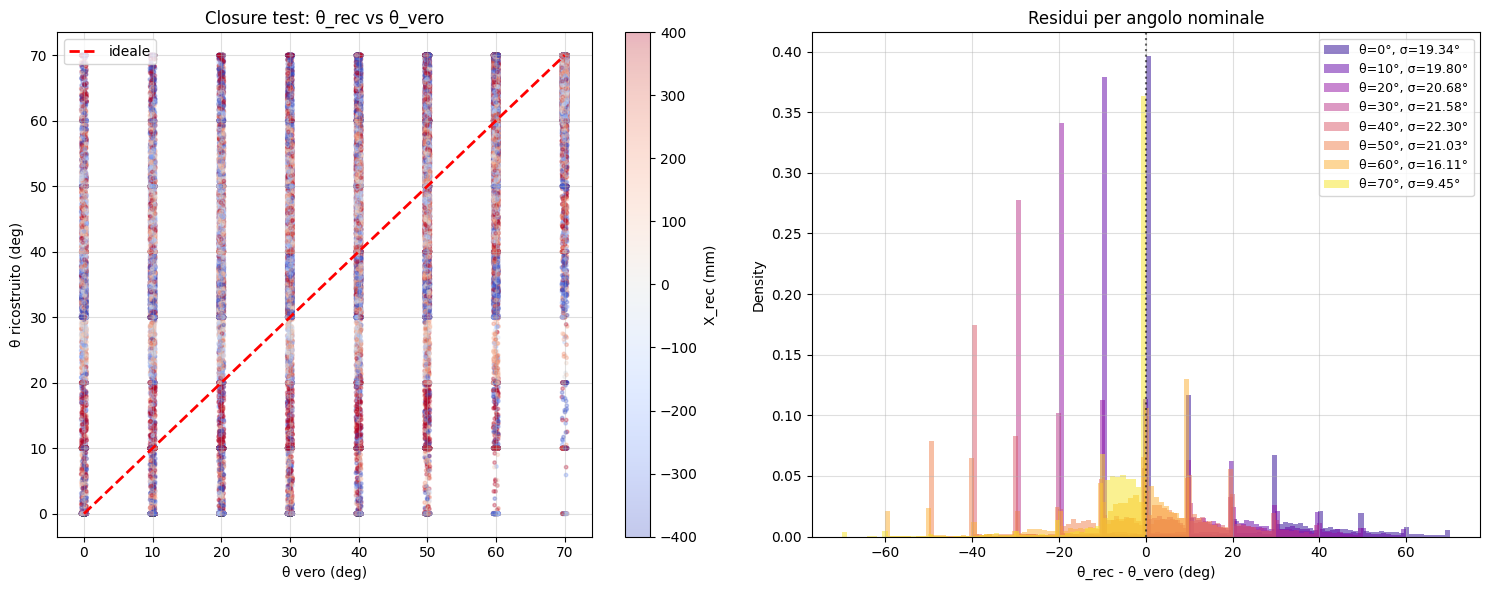

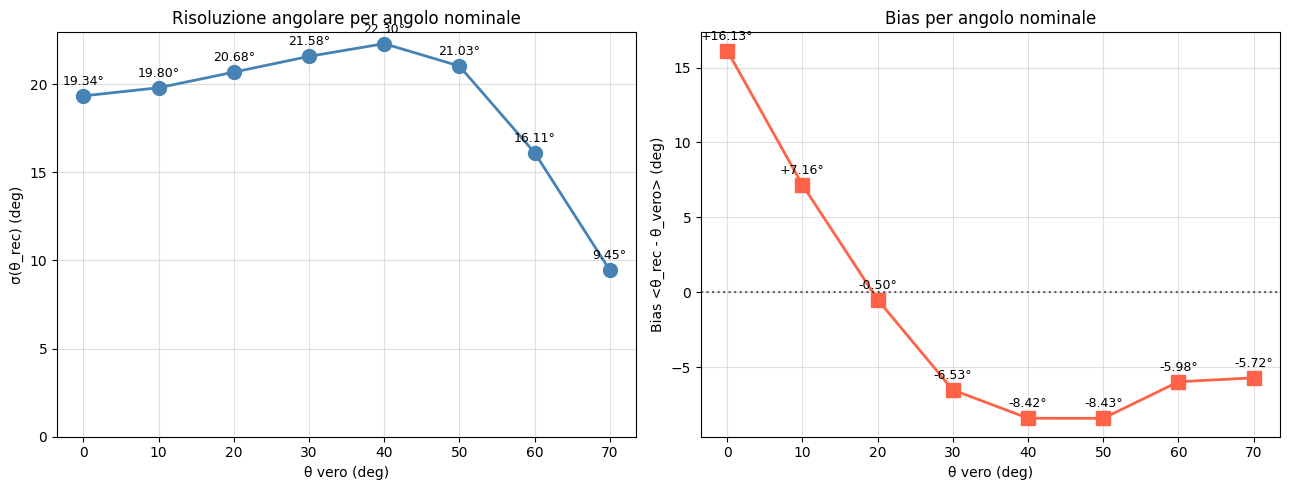

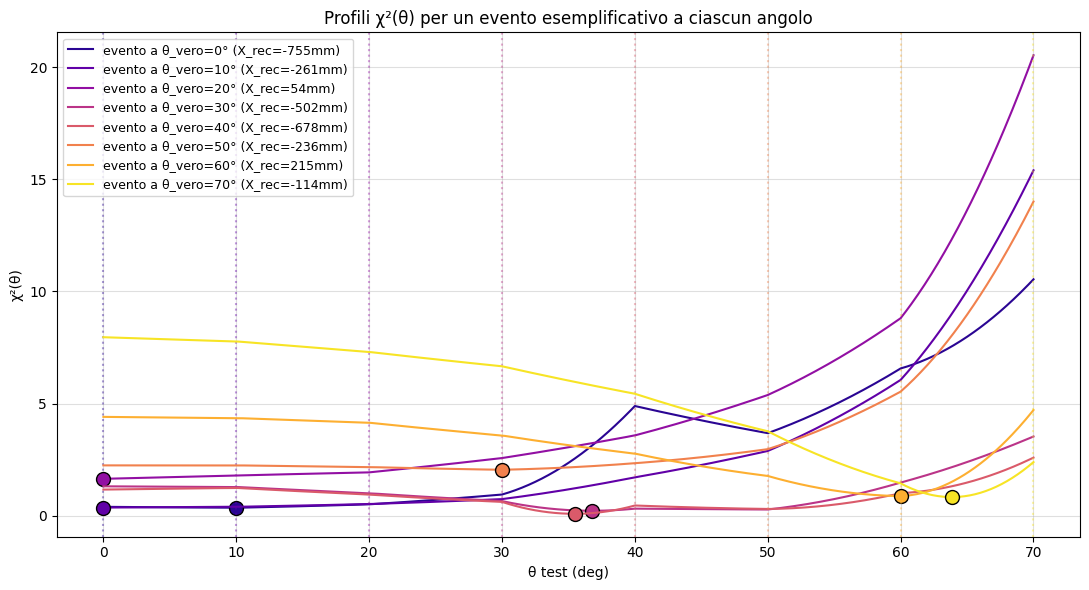

In [1]:
# %% [markdown]
# # Stimatore multivariato di θ — χ² 3D con closure test
#
# Costruisce uno stimatore dell'angolo di traccia θ partendo dal vettore di
# osservabili tridimensionale `(Q_SUM, N_peaks_SUM, OT_SUM)` per ciascun evento.
# X è trattato come parametro noto, ricostruito da `Δt` + `log(Q_R/Q_L)`
# (calibrazione del notebook precedente).
#
# **Strategia:**
# - Split MC in **training** (50%) e **test** (50%)
# - Sul training: costruisce mappa MC `μ(θ, X)` (mediata su Y) + matrice di
#   covarianza `C` globale 3×3 sui residui
# - Sul test: per ogni evento stima `θ_rec` minimizzando `χ²(θ)` su griglia fine
# - Confronto `θ_rec` vs `θ_vero`: bias, risoluzione, scatter
#
# **Range di θ:** [0°, 40°]. Quando saranno disponibili 50/60/70°, basta
# aggiornare `DEG_MAX = 70.0`.

# %% [markdown]
# ## 1. Setup e parametri

# %%
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# ─── Cartella MC ───
MC_DIR = "/Users/benussi/Testbeam2026_WC_single/data"

# ─── Range angolare per training/test (per ora 0–40°) ───
DEG_MIN = 0.0
DEG_MAX = 70.0

# ─── Digitizer ───
SAMPLE_RATE_GS = 2.5
DT_NS         = 1.0 / SAMPLE_RATE_GS
RECORD_LENGTH = 1024
BASELINE_ADC  = 3800
V_PP_MV       = 1000.0
ADC_BITS      = 12
LSB_MV        = V_PP_MV / (2**ADC_BITS)

# ─── Soglie e gate (allineate ai notebook precedenti) ───
OT_THRESHOLD_MV         = 5.0
PEAK_THRESHOLD_MV       = 5.0
PEAK_MIN_DISTANCE_NS    = 1.5
PEAK_MIN_PROMINENCE_MV  = 3.0
PEAK_MIN_DIST_SAMPLES   = max(int(PEAK_MIN_DISTANCE_NS / DT_NS), 1)
INTEGRAL_GATE_PRE_NS    = 2.0
INTEGRAL_GATE_POST_NS   = 100.0

# ─── ROI ───
TRIGGER_NS = 150.0
ROI_START_NS = TRIGGER_NS - 100.0
ROI_END_NS   = TRIGGER_NS + 59.0
ROI_START_SAMPLE = int(ROI_START_NS / DT_NS)
ROI_END_SAMPLE   = int(ROI_END_NS / DT_NS)

# ─── Vettore di osservabili usato nel χ² ───
OBS_NAMES = ['Q_SUM', 'N_peaks_SUM', 'OT_SUM']

# ─── Griglia di scansione per θ_rec ───
THETA_SCAN_STEP = 0.1   # gradi
THETA_SCAN = np.arange(DEG_MIN, DEG_MAX + THETA_SCAN_STEP, THETA_SCAN_STEP)

# ─── Seed per split riproducibile ───
RNG_SEED = 42

FNAME_REGEX = re.compile(
    r'sim_Z([+-]?\d+\.?\d*)_Y([+-]?\d+\.?\d*)_X([+-]?\d+\.?\d*)_([+-]?\d+\.?\d*)Deg\.npz',
    re.IGNORECASE
)

print(f"DT = {DT_NS} ns/sample")
print(f"Range θ: [{DEG_MIN}, {DEG_MAX}]° con step di scansione {THETA_SCAN_STEP}°")
print(f"Osservabili nel χ²: {OBS_NAMES}")


# %% [markdown]
# ## 2. Funzioni di calcolo (identiche ai notebook precedenti)

# %%
def parse_fname(fname):
    m = FNAME_REGEX.match(fname)
    if not m: return None
    return float(m.group(1)), float(m.group(2)), float(m.group(3)), float(m.group(4))


def summed_signal_mv(event_dict, channels):
    summed = np.zeros(RECORD_LENGTH, dtype=float)
    for ch in channels:
        key = f'ch_{ch}'
        if key not in event_dict: continue
        wf = event_dict[key].astype(float)
        summed += -(wf - BASELINE_ADC) * LSB_MV
    return summed


def compute_ot(summed_mv, threshold_mv, roi_start, roi_end):
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    above = summed_mv[roi_start:roi_end] > threshold_mv
    if not above.any():
        return 0.0, -1, -1
    idx_above = np.where(above)[0]
    rising_local = idx_above[0]
    below_after = np.where(~above[rising_local:])[0]
    if len(below_after) == 0:
        falling_local = len(above) - 1
    else:
        falling_local = rising_local + below_after[0] - 1
    ot_ns = (falling_local - rising_local + 1) * DT_NS
    return ot_ns, roi_start + rising_local, roi_start + falling_local


def _local_maxima(sig):
    if len(sig) < 3: return np.array([], dtype=int)
    d = np.diff(sig)
    rising = d[:-1] > 0
    falling = d[1:]  < 0
    return np.where(rising & falling)[0] + 1


def _prominence(sig, peaks):
    n = len(sig)
    out = np.empty(len(peaks), dtype=float)
    for k, p in enumerate(peaks):
        h = sig[p]
        left_min = h
        i = p - 1
        while i >= 0 and sig[i] <= h:
            if sig[i] < left_min: left_min = sig[i]
            i -= 1
        right_min = h
        i = p + 1
        while i < n and sig[i] <= h:
            if sig[i] < right_min: right_min = sig[i]
            i += 1
        out[k] = h - max(left_min, right_min)
    return out


def _find_peaks(sig, height=None, distance=None, prominence=None):
    peaks = _local_maxima(sig)
    if len(peaks) == 0: return peaks
    if height is not None:
        peaks = peaks[sig[peaks] >= height]
        if len(peaks) == 0: return peaks
    if prominence is not None and len(peaks) > 0:
        proms = _prominence(sig, peaks)
        peaks = peaks[proms >= prominence]
        if len(peaks) == 0: return peaks
    if distance is not None and distance > 1 and len(peaks) > 1:
        heights = sig[peaks]
        order = np.argsort(-heights)
        keep = np.ones(len(peaks), dtype=bool)
        for idx in order:
            if not keep[idx]: continue
            for other in range(len(peaks)):
                if other != idx and keep[other]:
                    if abs(peaks[other] - peaks[idx]) < distance:
                        keep[other] = False
        peaks = peaks[keep]
        peaks = np.sort(peaks)
    return peaks


def count_peaks(summed_mv, threshold_mv, roi_start, roi_end,
                min_dist_samples, min_prominence_mv, start_from=None):
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    if start_from is not None and start_from > roi_start:
        roi_start = start_from
    if roi_start >= roi_end: return 0
    sig = summed_mv[roi_start:roi_end]
    peaks_local = _find_peaks(sig, height=threshold_mv,
                              distance=min_dist_samples,
                              prominence=min_prominence_mv)
    return len(peaks_local)


def compute_integral(summed_mv, rising_sample, gate_pre_ns, gate_post_ns):
    if rising_sample < 0: return 0.0
    pre_samples  = int(round(gate_pre_ns  / DT_NS))
    post_samples = int(round(gate_post_ns / DT_NS))
    gate_start = max(0, rising_sample - pre_samples)
    gate_end   = min(RECORD_LENGTH, rising_sample + post_samples + 1)
    if gate_start >= gate_end: return 0.0
    return np.sum(summed_mv[gate_start:gate_end]) / LSB_MV

print('Funzioni caricate.')


# %% [markdown]
# ## 3. Loop sui file MC
#
# Filtra angoli ≤ DEG_MAX. Raccoglie le osservabili in `D` (dict di array).

# %%
print(f"Cerco file .npz in: {MC_DIR}")
files = sorted(glob.glob(os.path.join(MC_DIR, "*.npz")))
print(f"Trovati {len(files)} file totali.")

events = []
for fpath in files:
    fname = os.path.basename(fpath)
    parsed = parse_fname(fname)
    if parsed is None:
        continue
    Z_pos, Y_pos, X_pos, deg = parsed

    # Filtro angolare
    if not (DEG_MIN <= deg <= DEG_MAX):
        continue

    try:
        data = np.load(fpath, allow_pickle=True)
    except Exception as e:
        print(f"  [!] Errore lettura {fname}: {e}")
        continue

    for key_evt in data.files:
        ev = data[key_evt].item()

        wf_R = summed_signal_mv(ev, [0])
        wf_L = summed_signal_mv(ev, [1])
        wf_S = wf_R + wf_L

        ot_R, rR, _ = compute_ot(wf_R, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
        ot_L, rL, _ = compute_ot(wf_L, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
        ot_S, rS, _ = compute_ot(wf_S, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
        if ot_S <= 0:
            continue

        nS = count_peaks(wf_S, PEAK_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE,
                         PEAK_MIN_DIST_SAMPLES, PEAK_MIN_PROMINENCE_MV,
                         start_from=rS if rS >= 0 else None)

        Q_R = compute_integral(wf_R, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)
        Q_L = compute_integral(wf_L, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)
        Q_S = compute_integral(wf_S, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)

        t_R = rR * DT_NS if rR >= 0 else np.nan
        t_L = rL * DT_NS if rL >= 0 else np.nan
        dt  = (t_R - t_L) if (rR >= 0 and rL >= 0) else np.nan

        events.append({
            'deg': deg, 'X': X_pos, 'Y': Y_pos,
            'OT_SUM': ot_S, 'N_peaks_SUM': nS, 'Q_SUM': Q_S,
            'Q_R': Q_R, 'Q_L': Q_L, 'dt': dt,
        })

print(f"\nEventi totali (θ ≤ {DEG_MAX}°): {len(events)}")
keys_all = events[0].keys()
D = {k: np.array([e[k] for e in events], dtype=float) for k in keys_all}


# %% [markdown]
# ## 4. Calibrazione X dal MC (Δt + log(Q_R/Q_L), combinati)
#
# Rifittiamo qui i parametri per consistenza (non assumiamo i valori del notebook
# precedente, così è autonomo). Poi calcoliamo X_rec per ciascun evento.

# %%
mask_Q  = (D['Q_R'] > 0) & (D['Q_L'] > 0)
mask_dt = np.isfinite(D['dt'])

# --- log(Q_R/Q_L) ---
log_QR_QL = np.log(D['Q_R'][mask_Q] / D['Q_L'][mask_Q])
slope_Q, intercept_Q = np.polyfit(D['X'][mask_Q], log_QR_QL, 1)
X_from_Q_train = (log_QR_QL - intercept_Q) / slope_Q
sigma_X_Q = (X_from_Q_train - D['X'][mask_Q]).std()

# --- Δt ---
slope_dt, intercept_dt = np.polyfit(D['X'][mask_dt], D['dt'][mask_dt], 1)
X_from_T_train = (D['dt'][mask_dt] - intercept_dt) / slope_dt
sigma_X_T = (X_from_T_train - D['X'][mask_dt]).std()

print(f"=== Calibrazione X ===")
print(f"  log(Q_R/Q_L): slope = {slope_Q:+.5g}, intercept = {intercept_Q:+.3f}, sigma_X = {sigma_X_Q:.1f} mm")
print(f"  Δt:           slope = {slope_dt:+.5g}, intercept = {intercept_dt:+.3f}, sigma_X = {sigma_X_T:.1f} mm")


# %%
def reconstruct_X(Q_R, Q_L, dt):
    """Stima X dalla combinazione pesata di log(Q_R/Q_L) e Δt.
    Ritorna X_rec (mm) oppure NaN se l'evento non è ricostruibile."""
    X_rec = np.full_like(Q_R, np.nan, dtype=float)
    # Fattore di peso per ciascun metodo
    w_Q = 1.0 / sigma_X_Q**2
    w_T = 1.0 / sigma_X_T**2
    has_Q  = (Q_R > 0) & (Q_L > 0)
    has_T  = np.isfinite(dt)
    has_both = has_Q & has_T
    only_Q   = has_Q & (~has_T)
    only_T   = has_T & (~has_Q)

    ratio = np.where(has_Q, Q_R / np.where(Q_L > 0, Q_L, 1.0), 1.0)
    XQ = (np.log(ratio) - intercept_Q) / slope_Q
    
    XT = (np.where(has_T, dt, 0.0) - intercept_dt) / slope_dt
    X_rec[has_both] = (w_Q * XQ[has_both] + w_T * XT[has_both]) / (w_Q + w_T)
    X_rec[only_Q]   = XQ[only_Q]
    X_rec[only_T]   = XT[only_T]
    return X_rec


D['X_rec'] = reconstruct_X(D['Q_R'], D['Q_L'], D['dt'])
n_good_X = np.isfinite(D['X_rec']).sum()
sigma_X_combined = (D['X_rec'][np.isfinite(D['X_rec'])] -
                    D['X'][np.isfinite(D['X_rec'])]).std()
print(f"\nEventi con X_rec valido: {n_good_X}/{len(events)}")
print(f"sigma X combinata (training stesso): {sigma_X_combined:.1f} mm")


# %% [markdown]
# ## 5. Split MC: training 50% / test 50%
#
# Lo split è random (stratificato implicitamente perché gli eventi sono
# bilanciati). Sul training calcoliamo mappa μ e covarianza; sul test
# stimiamo θ.

# %%
rng = np.random.default_rng(RNG_SEED)
n_total = len(D['deg'])
mask_valid = np.isfinite(D['X_rec'])
all_idx = np.where(mask_valid)[0]
rng.shuffle(all_idx)
n_train = len(all_idx) // 2
idx_train = all_idx[:n_train]
idx_test  = all_idx[n_train:]

print(f"Eventi validi: {len(all_idx)}")
print(f"  Training: {len(idx_train)}")
print(f"  Test:     {len(idx_test)}")

# Subset training e test (solo le variabili che ci servono)
def subset(idx):
    return {k: D[k][idx] for k in D}

T = subset(idx_train)   # training
V = subset(idx_test)    # test (validation)


# %% [markdown]
# ## 6. Costruzione mappa MC μ(θ, X)
#
# Griglia: θ_grid × X_grid → vettore (Q_SUM, N_peaks_SUM, OT_SUM) mediato sui Y.

# %%
theta_grid = np.array(sorted(set(T['deg'])))
X_grid     = np.array(sorted(set(T['X'])))
print(f"Griglia θ: {theta_grid}")
print(f"Griglia X: {X_grid}")

mu_grid = np.zeros((len(theta_grid), len(X_grid), len(OBS_NAMES)), dtype=float)
n_grid  = np.zeros((len(theta_grid), len(X_grid)), dtype=int)

for i_t, theta_v in enumerate(theta_grid):
    for i_x, X_v in enumerate(X_grid):
        m = (T['deg'] == theta_v) & (T['X'] == X_v)
        if m.sum() == 0:
            continue
        for k, obs in enumerate(OBS_NAMES):
            mu_grid[i_t, i_x, k] = T[obs][m].mean()
        n_grid[i_t, i_x] = m.sum()

print(f"\nNumero medio di eventi per cella (θ, X) di training: {n_grid.mean():.0f}")
print(f"Min: {n_grid.min()}, Max: {n_grid.max()}")


# %% [markdown]
# ## 7. Matrice di covarianza globale C
#
# Calcolata sui RESIDUI `O - μ(θ_vero, X_vero)` di tutti gli eventi di training.
# Questo cattura solo la fluttuazione "intrinseca" delle osservabili, non lo
# spread tra punti diversi della griglia (che diventerebbe segnale).

# %%
# Per ogni evento di training, sottraggo la μ del suo (θ, X) di appartenenza
residuals = np.zeros((len(T['deg']), len(OBS_NAMES)), dtype=float)
for k, obs in enumerate(OBS_NAMES):
    residuals[:, k] = T[obs]

# Subtract per ogni evento la mu corrispondente
for i, (theta_v, X_v) in enumerate(zip(T['deg'], T['X'])):
    i_t = np.where(theta_grid == theta_v)[0][0]
    i_x = np.where(X_grid == X_v)[0][0]
    residuals[i] -= mu_grid[i_t, i_x]

C = np.cov(residuals.T)
C_inv = np.linalg.inv(C)

print("=== Matrice di covarianza globale C (sui residui) ===")
print(f"{'':<14} " + " ".join(f'{l:>14}' for l in OBS_NAMES))
for i, l in enumerate(OBS_NAMES):
    print(f"{l:<14} " + " ".join(f'{C[i,j]:>+14.3f}' for j in range(3)))

print("\nSqrt diagonale (σ delle fluttuazioni intrinseche):")
for k, l in enumerate(OBS_NAMES):
    print(f"  σ({l}) = {np.sqrt(C[k,k]):.2f}")




# %% [markdown]
# ## 7b. Diagnostica varianza: σ_within vs σ_between(Y)

# %%
# Decomposizione della varianza in ciascuna cella (θ, X):
#   σ²_total = σ²_within_Y + σ²_between_Y
# σ_within: fluttuazione intrinseca pulse-to-pulse a (θ, X, Y) fissato
# σ_between: variazione delle medie μ(θ, X, Y) tra le 5 Y
# Se σ_between >> σ_within, il problema è la Y ignota

Y_grid = np.array(sorted(set(T['Y'])))
print(f"Griglia Y: {Y_grid}")
print()
print(f"{'Osservabile':<14} {'σ_within':>12} {'σ_between(Y)':>15} {'rapporto':>12}")
print("-" * 60)

for k, obs in enumerate(OBS_NAMES):
    # Per ogni cella (θ, X, Y) calcolo media e varianza
    # σ_within²: media (sui Y, X, θ) delle varianze intra-cella
    # σ_between²: media (sui X, θ) delle varianze delle medie tra Y
    
    var_within_list  = []
    var_between_list = []
    for theta_v in theta_grid:
        for X_v in X_grid:
            means_per_Y = []
            for Y_v in Y_grid:
                m = (T['deg']==theta_v) & (T['X']==X_v) & (T['Y']==Y_v)
                if m.sum() < 5: continue
                arr = T[obs][m]
                var_within_list.append(arr.var())
                means_per_Y.append(arr.mean())
            if len(means_per_Y) >= 2:
                var_between_list.append(np.var(means_per_Y))
    
    sigma_within  = np.sqrt(np.mean(var_within_list))
    sigma_between = np.sqrt(np.mean(var_between_list))
    rapporto = sigma_between / sigma_within if sigma_within > 0 else np.nan
    print(f"{obs:<14} {sigma_within:>12.3f} {sigma_between:>15.3f} {rapporto:>12.2f}")


# %% [markdown]
# ## 7c. Quanto variano le osservabili con θ?
#
# Per ciascuna osservabile, stampa μ(θ, X=0) e la confronta con σ_within.
# Il rapporto Δμ/σ è il segnale-su-rumore "naturale" per il singolo evento.

# %%
i_X0 = np.where(X_grid == 0.0)[0][0]
sigma_within = np.array([1448.37, 1.01, 3.69])  # da diagnostica precedente

print(f"{'Osservabile':<14} " + " ".join(f'θ={t:>3.0f}°' for t in theta_grid))
print("-" * 60)
for k, obs in enumerate(OBS_NAMES):
    values = mu_grid[:, i_X0, k]
    line = f"{obs:<14} " + " ".join(f'{v:>7.2f}' for v in values)
    print(line)

print()
print(f"{'Osservabile':<14} {'Δμ(40-0)':>10} {'σ_within':>10} {'S/N':>6}")
print("-" * 50)
for k, obs in enumerate(OBS_NAMES):
    delta = mu_grid[-1, i_X0, k] - mu_grid[0, i_X0, k]
    snr = abs(delta) / sigma_within[k]
    print(f"{obs:<14} {delta:>+10.2f} {sigma_within[k]:>10.2f} {snr:>6.2f}")

    
# %% [markdown]
# ## 8. Interpolazione bilineare di μ(θ, X) — vettorializzata

# %%
def interp_mu_vec(theta_scalar, X_arr):
    """Interpolazione bilineare su griglia (theta_grid, X_grid).
    theta_scalar: float
    X_arr: array (N,)
    Ritorna: array (N, len(OBS_NAMES))
    Gli X fuori griglia vengono linearmente extrapolati dai due valori di bordo.
    """
    # Indice θ
    i_t = np.searchsorted(theta_grid, theta_scalar) - 1
    i_t = np.clip(i_t, 0, len(theta_grid) - 2)
    t_lo = theta_grid[i_t]
    t_hi = theta_grid[i_t + 1]
    f_t = (theta_scalar - t_lo) / (t_hi - t_lo)

    # Indice X (vettorizzato)
    i_x = np.searchsorted(X_grid, X_arr) - 1
    i_x = np.clip(i_x, 0, len(X_grid) - 2)
    x_lo = X_grid[i_x]
    x_hi = X_grid[i_x + 1]
    f_x = (X_arr - x_lo) / (x_hi - x_lo)  # (N,)

    # Quattro vertici dell'interpolazione bilineare
    mu_00 = mu_grid[i_t,     i_x]      # (N, 3)
    mu_01 = mu_grid[i_t,     i_x + 1]
    mu_10 = mu_grid[i_t + 1, i_x]
    mu_11 = mu_grid[i_t + 1, i_x + 1]

    f_x = f_x[:, None]
    mu = ((1 - f_t) * (1 - f_x) * mu_00 +
          f_t       * (1 - f_x) * mu_10 +
          (1 - f_t) * f_x       * mu_01 +
          f_t       * f_x       * mu_11)
    return mu


# Test sanity: interpolazione su un punto della griglia deve dare il valore esatto
test_mu = interp_mu_vec(10.0, np.array([0.0]))
true_mu = mu_grid[np.where(theta_grid == 10.0)[0][0],
                  np.where(X_grid == 0.0)[0][0]]
print(f"Test interpolazione a (θ=10, X=0):")
print(f"  Interpolato: {test_mu[0]}")
print(f"  Vero:        {true_mu}")
print(f"  Diff max: {np.abs(test_mu[0] - true_mu).max():.2e}")



# %% [markdown]
# ## 7d. Limite teorico di risoluzione: Cramér-Rao bound
#
# Per uno stimatore ottimale gaussiano con cov nota:
#   σ²_θ ≥ 1 / I(θ)        con I(θ) = (∂μ/∂θ)ᵀ C⁻¹ (∂μ/∂θ)
# Se 1/sqrt(I) ≈ 3°, lo stimatore attuale è sub-ottimale.
# Se 1/sqrt(I) ≈ 15°, abbiamo raggiunto il limite delle 3 osservabili.

# %%
# Stima ∂μ/∂θ con differenze finite centrali, a X=0
i_X0 = np.where(X_grid == 0.0)[0][0]
print(f"{'θ':>4} {'∂Q/∂θ':>10} {'∂N/∂θ':>8} {'∂OT/∂θ':>10} {'σ_θ (CR)':>10}")
print("-" * 50)
sigma_theta_CR_list = []
for i_t, theta_v in enumerate(theta_grid):
    # Differenza centrale (o forward/backward ai bordi)
    if i_t == 0:
        dmu_dtheta = (mu_grid[1, i_X0] - mu_grid[0, i_X0]) / (theta_grid[1] - theta_grid[0])
    elif i_t == len(theta_grid) - 1:
        dmu_dtheta = (mu_grid[-1, i_X0] - mu_grid[-2, i_X0]) / (theta_grid[-1] - theta_grid[-2])
    else:
        dmu_dtheta = (mu_grid[i_t+1, i_X0] - mu_grid[i_t-1, i_X0]) / (theta_grid[i_t+1] - theta_grid[i_t-1])
    # Fisher information
    I_theta = dmu_dtheta @ C_inv @ dmu_dtheta
    sigma_theta_CR = 1.0 / np.sqrt(I_theta) if I_theta > 0 else np.inf
    sigma_theta_CR_list.append(sigma_theta_CR)
    print(f"{theta_v:>4.0f} {dmu_dtheta[0]:>+10.2f} {dmu_dtheta[1]:>+8.3f} "
          f"{dmu_dtheta[2]:>+10.3f} {sigma_theta_CR:>10.2f}")

print(f"\nσ_θ (CR) medio: {np.mean(sigma_theta_CR_list):.2f}°  (limite teorico)")
print(f"σ_θ misurato:   ~15°  (notebook attuale)")



# %% [markdown]
# ## 9. Funzione χ² e stimatore di θ — vettorializzato
#
# Per ciascun evento di test scansiona THETA_SCAN, calcola χ²(θ) e prende il minimo.
# `X_rec` è preso da `reconstruct_X` (Δt + log(Q_R/Q_L)).

# %%
# Vettore osservabili del test set
O_test = np.column_stack([V[obs] for obs in OBS_NAMES])  # (N_test, 3)
X_rec_test = V['X_rec']  # (N_test,)

# Pre-allocate
N_test = len(O_test)
chi2_matrix = np.zeros((N_test, len(THETA_SCAN)), dtype=float)

print(f"Scansione χ² su {len(THETA_SCAN)} valori di θ per {N_test} eventi test...")
for k, theta in enumerate(THETA_SCAN):
    mu_k = interp_mu_vec(theta, X_rec_test)  # (N_test, 3)
    diff = O_test - mu_k                      # (N_test, 3)
    # chi2[i] = diff[i] @ C_inv @ diff[i]
    chi2_matrix[:, k] = np.einsum('ij,jk,ik->i', diff, C_inv, diff)

# Argmin per ciascun evento
idx_best = chi2_matrix.argmin(axis=1)
theta_rec = THETA_SCAN[idx_best]
chi2_min  = chi2_matrix[np.arange(N_test), idx_best]

print(f"\nDone.")
print(f"theta_rec: min = {theta_rec.min():.1f}°, max = {theta_rec.max():.1f}°, "
      f"mean = {theta_rec.mean():.1f}°")
print(f"χ²_min: median = {np.median(chi2_min):.2f} (atteso ~ {len(OBS_NAMES)} per fit buono)")


# %% [markdown]
# ## 10. Closure test: θ_rec vs θ_vero
#
# Scatter degli eventi test e calcolo di bias e σ per ciascun angolo nominale.

# %%
theta_true = V['deg']

# Tabella bias e σ per angolo nominale
print(f"\n=== Tabella performance ===")
print(f"  {'θ_true':>8} {'N':>8} {'<θ_rec>':>10} {'bias':>8} {'σ(θ_rec)':>10}")
for theta_v in sorted(set(theta_true)):
    m = theta_true == theta_v
    if m.sum() == 0: continue
    mean_rec = theta_rec[m].mean()
    sigma_rec = theta_rec[m].std()
    bias = mean_rec - theta_v
    print(f"  {theta_v:>8.0f} {int(m.sum()):>8d} {mean_rec:>10.2f} {bias:>+8.2f} {sigma_rec:>10.2f}")


# %%
# Plot principali
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: scatter θ_rec vs θ_true (con jitter sull'asse x per visibilità)
ax = axes[0]
jitter = np.random.uniform(-0.4, 0.4, size=N_test)
sc = ax.scatter(theta_true + jitter, theta_rec, c=X_rec_test, cmap='coolwarm',
                alpha=0.3, s=6, vmin=-400, vmax=400)
ax.plot([DEG_MIN, DEG_MAX], [DEG_MIN, DEG_MAX], 'r--', linewidth=2, label='ideale')
ax.set_xlabel('θ vero (deg)')
ax.set_ylabel('θ ricostruito (deg)')
ax.set_title('Closure test: θ_rec vs θ_vero')
ax.grid(alpha=0.4)
ax.legend()
plt.colorbar(sc, ax=ax, label='X_rec (mm)')

# Plot 2: histogram dei residui θ_rec - θ_true per angolo
ax = axes[1]
res = theta_rec - theta_true
unique_thetas = sorted(set(theta_true))
colors = plt.cm.plasma(np.linspace(0.05, 0.95, len(unique_thetas)))
for theta_v, c in zip(unique_thetas, colors):
    m = theta_true == theta_v
    if m.sum() == 0: continue
    ax.hist(res[m], bins=60, alpha=0.5, color=c, density=True,
            label=f'θ={theta_v:.0f}°, σ={res[m].std():.2f}°')
ax.axvline(0, color='black', linestyle=':', alpha=0.6)
ax.set_xlabel('θ_rec - θ_vero (deg)')
ax.set_ylabel('Density')
ax.set_title('Residui per angolo nominale')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 11. Risoluzione e bias vs angolo

# %%
# Grafico riassuntivo: σ(θ_rec) per angolo
unique_thetas = np.array(sorted(set(theta_true)))
sigmas = np.zeros(len(unique_thetas))
biases = np.zeros(len(unique_thetas))
for i, theta_v in enumerate(unique_thetas):
    m = theta_true == theta_v
    sigmas[i] = theta_rec[m].std()
    biases[i] = theta_rec[m].mean() - theta_v

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(unique_thetas, sigmas, 'o-', color='steelblue', markersize=10, linewidth=2)
ax.set_xlabel('θ vero (deg)')
ax.set_ylabel('σ(θ_rec) (deg)')
ax.set_title('Risoluzione angolare per angolo nominale')
ax.grid(alpha=0.4)
ax.set_ylim(bottom=0)
for x, y in zip(unique_thetas, sigmas):
    ax.annotate(f'{y:.2f}°', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)

ax = axes[1]
ax.plot(unique_thetas, biases, 's-', color='tomato', markersize=10, linewidth=2)
ax.axhline(0, color='black', linestyle=':', alpha=0.6)
ax.set_xlabel('θ vero (deg)')
ax.set_ylabel('Bias <θ_rec - θ_vero> (deg)')
ax.set_title('Bias per angolo nominale')
ax.grid(alpha=0.4)
for x, y in zip(unique_thetas, biases):
    ax.annotate(f'{y:+.2f}°', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# %% [markdown]
# ## 12. Esempio: profilo χ² di un singolo evento
#
# Mostra come la χ²(θ) appare per qualche evento di test, scelti uno per angolo.

# %%
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.plasma(np.linspace(0.05, 0.95, len(unique_thetas)))
for theta_v, c in zip(unique_thetas, colors):
    m = np.where(theta_true == theta_v)[0]
    if len(m) == 0: continue
    # Prendi il primo evento di questo angolo
    ev_idx = m[0]
    ax.plot(THETA_SCAN, chi2_matrix[ev_idx, :], '-', color=c, linewidth=1.5,
            label=f'evento a θ_vero={theta_v:.0f}° (X_rec={X_rec_test[ev_idx]:.0f}mm)')
    # Marker sul minimo
    best_idx = chi2_matrix[ev_idx, :].argmin()
    ax.plot(THETA_SCAN[best_idx], chi2_matrix[ev_idx, best_idx], 'o',
            color=c, markersize=10, markeredgecolor='black')
    # Linea verticale al θ_vero
    ax.axvline(theta_v, color=c, linestyle=':', alpha=0.4)

ax.set_xlabel('θ test (deg)')
ax.set_ylabel('χ²(θ)')
ax.set_title('Profili χ²(θ) per un evento esemplificativo a ciascun angolo')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


# %% [markdown]
# ## 13. Riepilogo e prossimi passi
#
# Dopo aver visto i risultati, le possibili strade:
#
# | Caso | Strategia successiva |
# |------|---------------------|
# | σ(θ_rec) < 3° su tutta la range | metodo solido, possiamo passare ai dati reali |
# | σ(θ_rec) > 5° a 0° (peggio a piccoli angoli) | normale: a 0° le osservabili saturano |
# | bias > 1° crescente con θ | mappa MC sotto-campionata o non-linearità → step più fine |
# | bias > 1° non monotono | qualche cella della griglia ha statistica bassa |
# | σ molto peggiore di sqrt(diag(C)) traspoto | osservabili poco sensibili a θ — aggiungere R/L? |
#
# **Estensioni naturali:**
# - Includere `(Q_R, Q_L)` separati nel vettore: passa da 3D a 5D, sfrutta l'asimmetria
# - Trattare X come nuisance e marginalizzare (Y stesso modo)
# - Aggiungere errore su X_rec come componente extra nel χ² (propagation di errori)
# - Aggiungere angoli 50/60/70 quando saranno disponibili (basta cambiare DEG_MAX)